# Child Identification Experiment

This notebook experiments with the single child identification system on real tracking results.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import sys
import os

# Add the feature processing directory to path
sys.path.append('/orcd/data/satra/001/users/brukew/sailsprep/feature_processing')

from single_child_identification import (
    Track, AnnotationInfo, ChildIdentificationConfig,
    identify_single_child, ChildResult, crop_bbox_from_frame
)

/home/brukew/miniconda3/envs/age_classification/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load the tracking JSON

In [2]:
json_path = "/orcd/data/satra/001/users/brukew/test_pose_export.json"

with open(json_path, 'r') as f:
    tracking_data = json.load(f)

print(f"Loaded tracking data from: {json_path}")
print(f"Video: {tracking_data['video_metadata']['input_path']}")
print(f"Total tracks: {len(tracking_data['tracking_results'])}")
print(f"FPS: {tracking_data['video_metadata']['fps']:.2f}")
print(f"Total frames: {tracking_data['video_metadata']['total_frames']}")

Loaded tracking data from: /orcd/data/satra/001/users/brukew/test_pose_export.json
Video: /orcd/data/satra/002/datasets/SAILS/Phase_III_Videos/Videos_from_external/H.L._Home_Videos_AMES_A6Y4Y7X2G1/12-16 month videos/Dec 2018 (14m)/12-29-2018.MOV
Total tracks: 7
FPS: 29.98
Total frames: 1835


In [3]:
def convert_tracking_json_to_tracks(tracking_data) -> list:
    """Convert tracking JSON results to Track objects for child identification"""
    tracks = []
    
    fps = tracking_data['video_metadata']['fps']
    video_path = tracking_data['video_metadata']['input_path']
    
    for track_id_str, track_data in tracking_data['tracking_results'].items():
        track_id = int(track_id_str)
        start_frame = track_data['start_frame']
        end_frame = track_data['end_frame']
        frames_data = track_data['frames']
        
        # Extract keypoints and bboxes for all frames
        keypoints_list = []
        bboxes_list = []
        frame_numbers = []
        
        # Get all frame numbers and sort them
        sorted_frame_nums = sorted([int(f) for f in frames_data.keys()])
        
        for frame_num in sorted_frame_nums:
            frame_str = str(frame_num)
            if frame_str in frames_data:
                frame_info = frames_data[frame_str]
                
                # Store keypoints as numpy array
                keypoints = np.array(frame_info['keypoints'])
                keypoints_list.append(keypoints)
                
                # Store bbox as tuple
                bbox = tuple(frame_info['bbox'])
                bboxes_list.append(bbox)
                
                # Store frame number
                frame_numbers.append(frame_num)
        
        # Create Track object with video path and frame numbers
        track = Track(
            id=track_id,
            start_frame=start_frame,
            end_frame=end_frame,
            fps=fps,
            keypoints=keypoints_list,
            bboxes=bboxes_list,
            face_crops=None,  # We don't have face crops in our JSON
            video_path=video_path,  # Add video path for bbox-based age estimation
            frame_numbers=frame_numbers,  # Add frame numbers
            meta={
                'total_detections': len(frame_numbers),
                'frame_numbers': frame_numbers
            }
        )
        
        tracks.append(track)
    
    return tracks

# Convert the data
tracks = convert_tracking_json_to_tracks(tracking_data)

print(f"Converted {len(tracks)} tracks:")
for track in tracks:
    print(f"  Track {track.id}: frames {track.start_frame}-{track.end_frame} "
          f"({track.duration_frames()} frames, {track.duration_seconds():.1f}s)")
    print(f"    Video path: {track.video_path}")
    print(f"    Frame numbers: {len(track.frame_numbers)} frames")

Converted 7 tracks:
  Track 1: frames 1-391 (391 frames, 13.0s)
    Video path: /orcd/data/satra/002/datasets/SAILS/Phase_III_Videos/Videos_from_external/H.L._Home_Videos_AMES_A6Y4Y7X2G1/12-16 month videos/Dec 2018 (14m)/12-29-2018.MOV
    Frame numbers: 391 frames
  Track 2: frames 433-1652 (1220 frames, 40.7s)
    Video path: /orcd/data/satra/002/datasets/SAILS/Phase_III_Videos/Videos_from_external/H.L._Home_Videos_AMES_A6Y4Y7X2G1/12-16 month videos/Dec 2018 (14m)/12-29-2018.MOV
    Frame numbers: 972 frames
  Track 3: frames 482-482 (1 frames, 0.0s)
    Video path: /orcd/data/satra/002/datasets/SAILS/Phase_III_Videos/Videos_from_external/H.L._Home_Videos_AMES_A6Y4Y7X2G1/12-16 month videos/Dec 2018 (14m)/12-29-2018.MOV
    Frame numbers: 1 frames
  Track 4: frames 521-522 (2 frames, 0.1s)
    Video path: /orcd/data/satra/002/datasets/SAILS/Phase_III_Videos/Videos_from_external/H.L._Home_Videos_AMES_A6Y4Y7X2G1/12-16 month videos/Dec 2018 (14m)/12-29-2018.MOV
    Frame numbers: 2 frame

In [5]:
# Create annotation info - assume this is a ~14 month old child based on video name
annotations = AnnotationInfo(
    age_in_months=14.0,  # Based on "Dec 2018 (14m)" in video path
    quality_flags={}
)

# Create configuration - adjust for this scenario
config = ChildIdentificationConfig(
    # Sampling settings
    sampling_percentage=0.15,  # Sample fewer frames to speed up processing
    sampling_max_frames_per_track=20,  # Limit to 40 frames per track
    min_track_frames=10,  # Lower threshold since we have short tracks
    
    # Age settings  
    age_child_years_threshold=10.0,  # Under 10 years = child
    age_tau=2.5,
    face_conf_threshold=0.5,  # Lower threshold for bbox crops
    
    # Weights - enable age estimation from bboxes
    w_age_default=1.0,
    w_skel_default=0.0,  # Not implemented yet
    
    # Continuity settings
    continuity_gap_seconds=2.0,  # Allow 2 second gaps
    intra_id_gamma=0.3,  # Same-ID bonus
    intra_id_tau=1.0     # Decay parameter
)

print(f"Configuration:")
print(f"  Min track frames: {config.min_track_frames}")
print(f"  Continuity gap: {config.continuity_gap_seconds}s")
print(f"  Age threshold: {config.age_child_years_threshold} years")
print(f"  Expected child age: {annotations.age_in_months} months ({annotations.age_in_months/12:.1f} years)")
print(f"  Sampling: {config.sampling_percentage*100}% of frames, max {config.sampling_max_frames_per_track} per track")
print(f"  Face confidence threshold: {config.face_conf_threshold}")

# Check if video file exists for age estimation
video_path = tracking_data['video_metadata']['input_path']
import os
if os.path.exists(video_path):
    print(f"✓ Video file found - age estimation from bboxes will be attempted")
else:
    print(f"⚠ Video file not found - age estimation will be skipped")
    print(f"  Expected path: {video_path}")

Configuration:
  Min track frames: 10
  Continuity gap: 2.0s
  Age threshold: 10.0 years
  Expected child age: 14.0 months (1.2 years)
  Sampling: 15.0% of frames, max 20 per track
  Face confidence threshold: 0.5
✓ Video file found - age estimation from bboxes will be attempted


# Run the child identification

In [6]:
print("Running child identification...")
print("Note: Will attempt age estimation from bounding box crops if video is available")

try:
    child_result = identify_single_child(tracks, annotations, config)
    
    print(f"\n=== CHILD IDENTIFICATION RESULTS ===")
    print(f"Selected track ID sequence: {child_result.child_track_id_sequence}")
    print(f"Number of segments: {len(child_result.segments)}")
    print(f"Confidence: {child_result.confidence:.3f}")
    print(f"Uncertainty: {child_result.uncertainty}")
    
    # Calculate total duration
    total_duration = sum(seg.duration_seconds() for seg in child_result.segments)
    total_frames = sum(seg.duration_frames() for seg in child_result.segments)
    
    print(f"\nChild timeline:")
    print(f"  Total duration: {total_duration:.1f} seconds ({total_frames} frames)")
    
    for i, segment in enumerate(child_result.segments):
        print(f"  Segment {i+1}: Track {segment.id}, frames {segment.start_frame}-{segment.end_frame} "
              f"({segment.duration_seconds():.1f}s)")
    
except Exception as e:
    print(f"Error during child identification: {e}")
    import traceback
    traceback.print_exc()

Running child identification...
Note: Will attempt age estimation from bounding box crops if video is available


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.



=== CHILD IDENTIFICATION RESULTS ===
Selected track ID sequence: [1, 2]
Number of segments: 2
Confidence: 0.877
Uncertainty: None

Child timeline:
  Total duration: 53.7 seconds (1611 frames)
  Segment 1: Track 1, frames 1-391 (13.0s)
  Segment 2: Track 2, frames 433-1652 (40.7s)


## Analyze the Results

In [7]:
# Analyze the diagnostics
if 'child_result' in locals():
    diagnostics = child_result.diagnostics
    nodes = diagnostics['nodes']
    edges = diagnostics['edges']
    path_indices = diagnostics['path_indices']
    
    print(f"=== DETAILED ANALYSIS ===")
    print(f"Total nodes (tracklets): {len(nodes)}")
    print(f"Total edges: {len(edges)}")
    print(f"Selected path length: {len(path_indices)}")
    
    # Node analysis
    print(f"\nNode scores:")
    for i, node in enumerate(nodes):
        selected = "✓" if i in path_indices else " "
        print(f"  {selected} Node {i}: Track {node.tracklet.id}, "
              f"score={node.score:.3f}, weight={node.weight:.1f}, "
              f"duration={node.tracklet.duration_seconds():.1f}s")
        
        # Show evidence flags
        if node.evidence.flags:
            print(f"      Flags: {', '.join(node.evidence.flags)}")
    
    # Edge analysis
    print(f"\nEdge scores:")
    for edge in edges:
        src_track = nodes[edge.src_index].tracklet.id
        dst_track = nodes[edge.dst_index].tracklet.id
        print(f"  Track {src_track} → Track {dst_track}: score={edge.score:.3f}")
        for reason, value in edge.reasons.items():
            print(f"    {reason}: {value:.3f}")

=== DETAILED ANALYSIS ===
Total nodes (tracklets): 4
Total edges: 1
Selected path length: 2

Node scores:
  ✓ Node 0: Track 1, score=0.978, weight=12.7, duration=13.0s
      Flags: body_filter_failed_391_Too few visible keypoints: 3 < 4, skeleton_unimplemented
  ✓ Node 1: Track 2, score=0.777, weight=31.6, duration=40.7s
      Flags: body_filter_failed_433_Too few visible keypoints: 2 < 4, skeleton_unimplemented
    Node 2: Track 5, score=0.100, weight=0.7, duration=6.5s
      Flags: skeleton_unimplemented
    Node 3: Track 6, score=0.317, weight=2.4, duration=7.6s
      Flags: skeleton_unimplemented

Edge scores:
  Track 1 → Track 2: score=0.300
    temporal: 0.300


## Visualize Track Selection

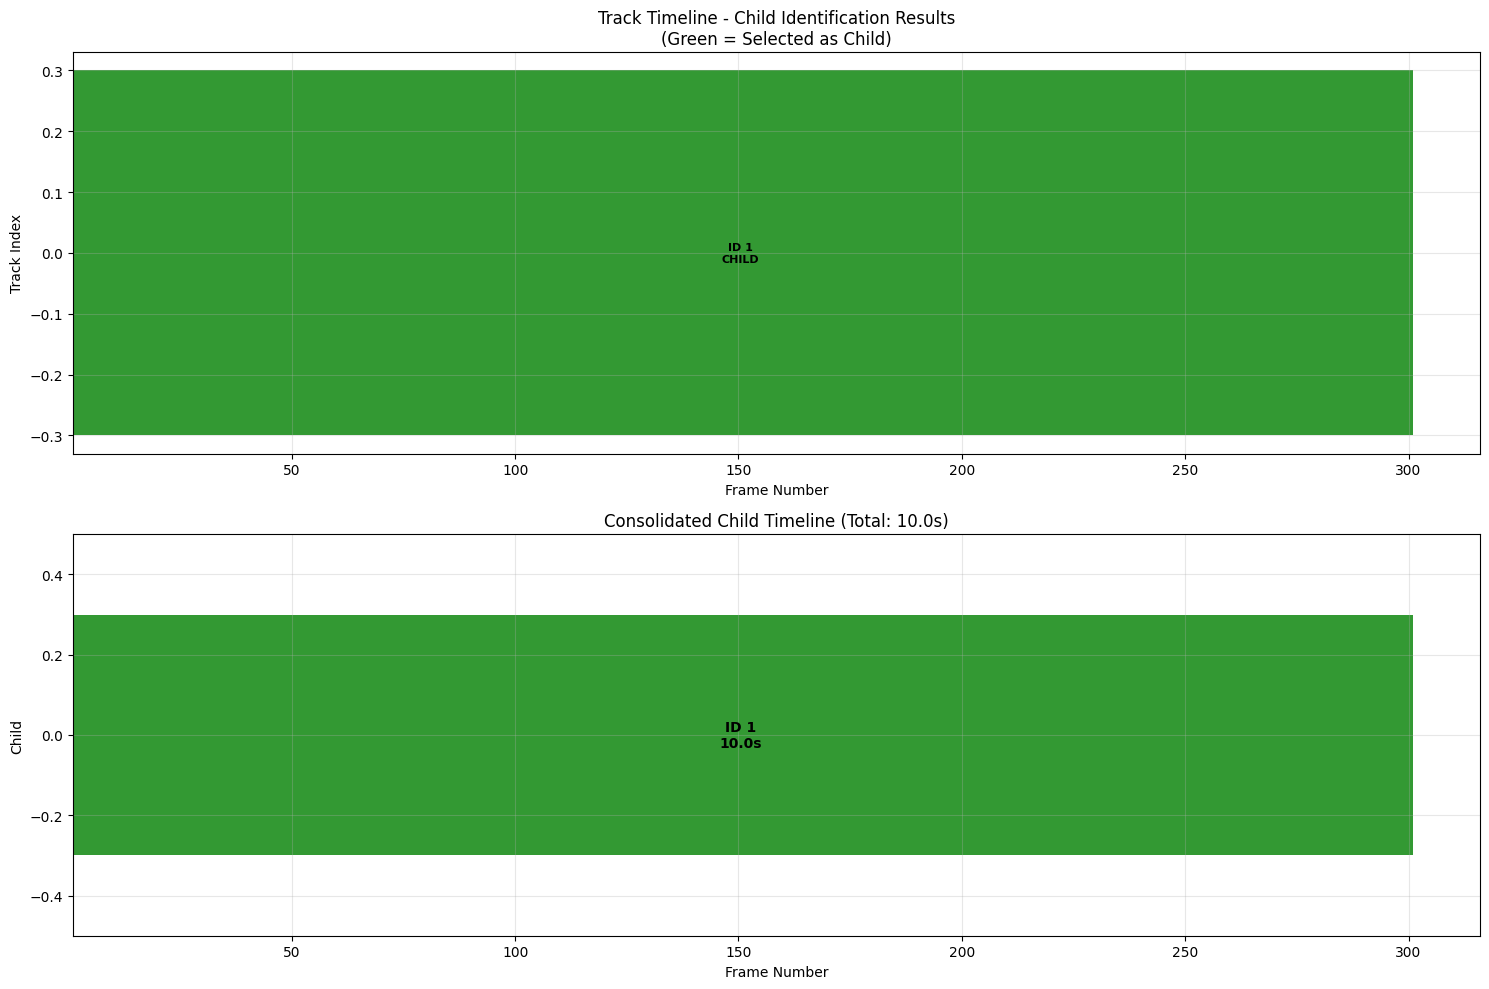


=== TRACK SUMMARY ===
 track_id  start_frame  end_frame  duration_sec  selected
        1            1        300        10.005      True


In [7]:
if 'child_result' in locals():
    # Create timeline visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
    
    # Top plot: All tracks with selection overlay
    track_info = []
    selected_tracks = set(child_result.child_track_id_sequence)
    
    for i, track in enumerate(tracks):
        color = 'green' if track.id in selected_tracks else 'lightblue'
        alpha = 0.8 if track.id in selected_tracks else 0.4
        
        ax1.barh(i, track.duration_frames(), left=track.start_frame, 
                height=0.6, color=color, alpha=alpha)
        
        # Add text annotation
        mid_point = (track.start_frame + track.end_frame) / 2
        status = "CHILD" if track.id in selected_tracks else ""
        ax1.text(mid_point, i, f'ID {track.id}\n{status}', 
                ha='center', va='center', fontsize=8, fontweight='bold')
        
        track_info.append({
            'track_id': track.id,
            'start_frame': track.start_frame,
            'end_frame': track.end_frame,
            'duration_sec': track.duration_seconds(),
            'selected': track.id in selected_tracks
        })
    
    ax1.set_xlabel('Frame Number')
    ax1.set_ylabel('Track Index')
    ax1.set_title('Track Timeline - Child Identification Results\n(Green = Selected as Child)')
    ax1.grid(True, alpha=0.3)
    
    # Bottom plot: Just the child timeline
    if child_result.segments:
        for i, segment in enumerate(child_result.segments):
            ax2.barh(0, segment.duration_frames(), left=segment.start_frame,
                    height=0.6, color='green', alpha=0.8)
            
            # Add segment labels
            mid_point = (segment.start_frame + segment.end_frame) / 2
            ax2.text(mid_point, 0, f'ID {segment.id}\n{segment.duration_seconds():.1f}s',
                    ha='center', va='center', fontsize=10, fontweight='bold')
        
        ax2.set_xlabel('Frame Number')
        ax2.set_ylabel('Child')
        ax2.set_title(f'Consolidated Child Timeline (Total: {total_duration:.1f}s)')
        ax2.set_ylim(-0.5, 0.5)
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary table
    df = pd.DataFrame(track_info)
    print("\n=== TRACK SUMMARY ===")
    print(df.to_string(index=False))

## Compare with Original Tracking

In [8]:
if 'child_result' in locals():
    print("=== COMPARISON: ORIGINAL vs CHILD IDENTIFICATION ===")
    
    # Original tracking stats
    total_original_duration = sum(track.duration_seconds() for track in tracks)
    longest_original_track = max(tracks, key=lambda t: t.duration_seconds())
    
    print(f"\nOriginal tracking:")
    print(f"  Total tracks: {len(tracks)}")
    print(f"  Total duration: {total_original_duration:.1f}s")
    print(f"  Longest track: ID {longest_original_track.id} ({longest_original_track.duration_seconds():.1f}s)")
    print(f"  Average track duration: {total_original_duration/len(tracks):.1f}s")
    
    # Child identification stats
    child_duration = sum(seg.duration_seconds() for seg in child_result.segments)
    
    print(f"\nChild identification:")
    print(f"  Selected tracks: {len(child_result.child_track_id_sequence)}")
    print(f"  Child duration: {child_duration:.1f}s")
    print(f"  Coverage: {child_duration/total_original_duration*100:.1f}% of total tracking")
    print(f"  Segments: {len(child_result.segments)}")
    
    # Check if the longest track was selected
    longest_selected = longest_original_track.id in child_result.child_track_id_sequence
    print(f"  Longest original track selected: {'Yes' if longest_selected else 'No'}")
    
    # Show gaps in child timeline
    if len(child_result.segments) > 1:
        print(f"\nGaps in child timeline:")
        for i in range(len(child_result.segments) - 1):
            seg1 = child_result.segments[i]
            seg2 = child_result.segments[i + 1]
            gap_frames = seg2.start_frame - seg1.end_frame
            gap_seconds = gap_frames / child_result.segments[0].fps
            print(f"  Gap {i+1}: {gap_frames} frames ({gap_seconds:.1f}s) between Track {seg1.id} and {seg2.id}")

=== COMPARISON: ORIGINAL vs CHILD IDENTIFICATION ===

Original tracking:
  Total tracks: 1
  Total duration: 10.0s
  Longest track: ID 1 (10.0s)
  Average track duration: 10.0s

Child identification:
  Selected tracks: 1
  Child duration: 10.0s
  Coverage: 100.0% of total tracking
  Segments: 1
  Longest original track selected: Yes


## Export Results

In [11]:
if 'child_result' in locals():
    # Create output directory
    output_dir = Path(json_path).parent / "child_identification_results"
    output_dir.mkdir(exist_ok=True)
    
    # Export child timeline summary
    video_name = Path(json_path).stem.replace('_tracking', '')
    summary_path = output_dir / f"{video_name}_child_timeline.json"
    
    export_data = {
        'video_info': {
            'source_video': tracking_data['video_metadata']['input_path'],
            'tracking_file': json_path,
            'fps': tracking_data['video_metadata']['fps'],
            'total_frames': tracking_data['video_metadata']['total_frames']
        },
        'child_identification': {
            'selected_track_ids': child_result.child_track_id_sequence,
            'confidence': child_result.confidence,
            'total_duration_seconds': sum(seg.duration_seconds() for seg in child_result.segments),
            'segments': [
                {
                    'track_id': seg.id,
                    'start_frame': seg.start_frame,
                    'end_frame': seg.end_frame,
                    'duration_seconds': seg.duration_seconds()
                }
                for seg in child_result.segments
            ]
        },
        'config': {
            'min_track_frames': config.min_track_frames,
            'continuity_gap_seconds': config.continuity_gap_seconds,
            'age_threshold_years': config.age_child_years_threshold
        }
    }
    
    with open(summary_path, 'w') as f:
        json.dump(export_data, f, indent=2)
    
    print(f"Child identification results exported to: {summary_path}")
    
    # Also export the track comparison CSV
    csv_path = output_dir / f"{video_name}_track_comparison.csv"
    df.to_csv(csv_path, index=False)
    print(f"Track comparison exported to: {csv_path}")

Child identification results exported to: /orcd/data/satra/002/projects/SAILS/feature_processing/pipeline_outputs/tracking_exports/child_identification_results/12-29-2018_child_timeline.json
Track comparison exported to: /orcd/data/satra/002/projects/SAILS/feature_processing/pipeline_outputs/tracking_exports/child_identification_results/12-29-2018_track_comparison.csv
